# Практична робота № 3 — Перенавчання, складність моделі та регуляризація

**Варіант 5.** Набір даних: **Breast Cancer Wisconsin (Diagnostic)** — той самий, що
в ПР № 1, ЛР № 1 і ПР № 2, як прямо вимагає завдання ("використайте той самий
індивідуальний набір даних для задачі регресії").

**Мета роботи.** Експериментально виявити недонавчання і перенавчання, дослідити
залежність узагальнення від складності моделі, застосувати L1-, L2- та комбіновану
регуляризацію, вибрати силу регуляризації без використання тестової вибірки,
оцінити стійкість рішення.

Повний EDA не повторюється — використовуються рішення, зафіксовані в ПР № 1
(препроцесинг), ЛР № 1 (мультиколінеарність ознак) і ПР № 2 (порівняння моделей,
train/test split). Робота зосереджена на новій темі — впливі складності й
регуляризації на узагальнювальну здатність.


In [1]:
import time
import warnings
from math import comb
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, KFold, cross_validate, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.exceptions import ConvergenceWarning

RANDOM_STATE = 42
FIG = Path("../figures")
FIG.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)

data = load_breast_cancer(as_frame=True)
df = data.frame.rename(columns={c: c.replace(" ", "_") for c in data.frame.columns})
df = df.rename(columns={"target": "diagnosis"})
print(df.shape)


(569, 31)


## 1. Гіпотези та експериментальна задача

До запуску коду фіксуються чотири перевірювані гіпотези.

| № | Гіпотеза | Що обчислюється | Підтвердить | Спростує |
|---|---|---|---|---|
| H1 | Train RMSE не зростає зі збільшенням степеня полінома `d` | train RMSE для `d = 1…6` | монотонне (нестрого) спадання | будь-яке зростання |
| H2 | CV RMSE спочатку спадає, потім зростає через перенавчання | CV RMSE, SD, розрив `G` для тих самих `d` | мінімум у середині діапазону + зростання `G` після нього | монотонне спадання CV RMSE |
| H3 | Помірна регуляризація складної моделі (`d=4`) зменшує CV RMSE, розрив `G` **і** норму коефіцієнтів одночасно | CV RMSE, `G`, ‖w‖₁, ‖w‖₂, `N_nonzero` для Ridge/Lasso/ElasticNet проти нерегуляризованої моделі | усі три величини зменшуються разом | покращується лише метрика, а норма чи розрив — ні |
| H4 | Надмірна сила регуляризації спричиняє недонавчання: train- і CV-похибки зростають і зближуються | train/CV RMSE вздовж сітки `alpha` | зростання обох похибок при великих `alpha` | CV RMSE не зростає ні за яких `alpha` з дослідженої сітки |

**Основна метрика — RMSE**, та сама, що в ПР № 2 (та ж природа задачі — регресія
з бінарною ціллю у форматі 0/1).


## 2. Експериментальний протокол

Фіксується **до** перегляду будь-яких результатів.

| Компонент | Значення |
|---|---|
| Train/test split | 80/20, стратифікація за ціллю, `random_state=42` — **той самий**, що в ПР № 1/ЛР № 1/ПР № 2 |
| Схема CV | `KFold(5, shuffle=True, random_state=42)` — одна схема для всіх кандидатів |
| Метрика | RMSE (додатково MAE, R² лише на фінальному тесті) |
| Початковий Pipeline | `PolynomialFeatures(include_bias=False) → StandardScaler → модель` |
| Степені полінома | `d ∈ {1, 2, 3, 4, 5, 6}` |
| Сітка `alpha` | `np.logspace(-6, 3, 13)` — логарифмічна, звужена проти прикладу методички (19 точок) з міркувань бюджету часу; діапазон (від практичної відсутності штрафу до надмірного) збережено повністю |
| Сітка `l1_ratio` (Elastic Net) | `{0.2, 0.5, 0.8}` |
| Критерій вибору фінальної моделі | мінімальний CV RMSE; за різниці в межах правила однієї стандартної похибки — простіша/стійкіша модель |
| Момент відкриття test set | один раз, після фіксації фінальної конфігурації |

Test set — **той самий**, що вже оцінювався в ПР № 2. Це методологічне обмеження
(п. 10): результат фінального тесту не є повністю незалежною перевіркою, оскільки
ця вибірка вже брала участь у попередній роботі (хоч і не в процедурі вибору моделі
цієї роботи). Основними свідченнями для вибору моделі є CV та перевірка стійкості.


In [2]:
X_full = df.drop(columns="diagnosis")
y = df["diagnosis"].astype(float)

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f"|D_train| = {len(X_train_full)}   |D_test| = {len(X_test_full)}")
print(cv)


|D_train| = 455   |D_test| = 114
KFold(n_splits=5, random_state=42, shuffle=True)


## 3. Відбір ознак для поліноміального розширення

**Чому не всі 30 ознак.** Кількість поліноміальних ознак степеня `d` для `p`
вихідних ознак дорівнює $\binom{p+d}{d} - 1$. Для `p=30` вже `d=2` дає 495 ознак —
**більше**, ніж 455 об'єктів навчальної вибірки. Модель тоді точно інтерполює
навчальні дані (train RMSE = 0), а CV RMSE вибухає — драбини складності
"недонавчання → оптимум → перенавчання" просто не існує, є лише стрибок від
слабкого недонавчання до катастрофи. Це перевірено емпірично нижче.

**Рішення.** Методичка прямо дозволяє "обґрунтовано обрати невелику підмножину
числових ознак" (п. 3). Відбираю 6 ознак жадібним алгоритмом: беру ознаки за
спаданням $|r(x_j, y)|$, відкидаючи ті, що мають $|r| > 0.9$ з уже обраними —
щоб не заносити в поліноміальне розширення пари ознак, які й без степенів майже
лінійно залежні (це вже виявлено в ЛР № 1: 15 пар з $|r| > 0.95$).


In [3]:
corr_with_target = X_train_full.corrwith(y_train).abs().sort_values(ascending=False)

selected = []
for feat in corr_with_target.index:
    if all(abs(X_train_full[feat].corr(X_train_full[t])) <= 0.9 for t in selected):
        selected.append(feat)
    if len(selected) == 6:
        break

max_pairwise = max(
    abs(X_train_full[a].corr(X_train_full[b]))
    for i, a in enumerate(selected) for b in selected[i + 1:]
)

print("Обрані ознаки (за спаданням |corr| з ціллю, |r|<=0.9 між собою):")
for f in selected:
    print(f"  {f:26s}  |corr|={corr_with_target[f]:.3f}")
print(f"максимальна попарна |r| серед обраних: {max_pairwise:.3f}")

X_train, X_test = X_train_full[selected], X_test_full[selected]


Обрані ознаки (за спаданням |corr| з ціллю, |r|<=0.9 між собою):
  worst_concave_points        |corr|=0.798
  worst_perimeter             |corr|=0.783
  mean_concavity              |corr|=0.692
  worst_concavity             |corr|=0.668
  mean_compactness            |corr|=0.611
  worst_compactness           |corr|=0.602
максимальна попарна |r| серед обраних: 0.896


**Перевірка, чому не всі 30 ознак — програмно.** Оцінка кількості ознак
$p_{poly} = \binom{p+d}{d} - 1$ для обох варіантів `p`, і фактична перевірка
на всіх 30 ознаках при `d=2`.


In [4]:
def n_poly_features(p, d):
    return comb(p + d, d) - 1

print("Оцінка кількості ознак ДО запуску PolynomialFeatures:")
print(f"{'d':>2} {'p=30 (усі)':>12} {'p=6 (обрані)':>14}")
for d in range(1, 7):
    print(f"{d:>2} {n_poly_features(30, d):>12} {n_poly_features(6, d):>14}")

# Контрольна перевірка на всіх 30 ознаках (щоб не декларувати проблему, а показати її)
pipe_all30_d2 = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scale", StandardScaler()),
    ("model", LinearRegression()),
])
scores_all30 = cross_validate(
    pipe_all30_d2, X_train_full, y_train, cv=cv,
    scoring="neg_root_mean_squared_error", return_train_score=True,
)
print(f"\nКонтроль: усі 30 ознак, d=2 -> {n_poly_features(30, 2)} поліноміальних ознак")
print(f"  train RMSE = {-scores_all30['train_score'].mean():.4f}")
print(f"  CV RMSE    = {-scores_all30['test_score'].mean():.4f}  (порівняй із std(y)={y_train.std():.4f})")


Оцінка кількості ознак ДО запуску PolynomialFeatures:
 d   p=30 (усі)   p=6 (обрані)
 1           30              6
 2          495             27
 3         5455             83
 4        46375            209
 5       324631            461
 6      1947791            923



Контроль: усі 30 ознак, d=2 -> 495 поліноміальних ознак
  train RMSE = 0.0000
  CV RMSE    = 3.4584  (порівняй із std(y)=0.4843)


Train RMSE впритул до нуля, а CV RMSE у рази більший за розкид самої цілі —
модель на 495 ознаках і 455 об'єктах не узагальнює взагалі. Це підтверджує
рішення звузити простір ознак до 6 обраних, де на всіх шести степенях
($d \le 6 \Rightarrow$ до 923 ознак при `p=6`) кількість ознак залишається
в розумному співвідношенні до вибірки, а найгірший випадок усе ще менший за
кількість обʼєктів там, де це важливо (детальніше — у розділі 4).


## 4. Крива валідації: сімейство поліномів різної складності


In [5]:
rows = []
for d in range(1, 7):
    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("scale", StandardScaler()),
        ("model", LinearRegression()),
    ])
    t0 = time.perf_counter()
    scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring="neg_root_mean_squared_error", return_train_score=True,
    )
    elapsed = time.perf_counter() - t0

    train_rmse = -scores["train_score"]
    cv_rmse = -scores["test_score"]
    rows.append({
        "degree": d,
        "n_features": n_poly_features(6, d),
        "train_rmse": train_rmse.mean(),
        "cv_rmse": cv_rmse.mean(),
        "cv_sd": cv_rmse.std(ddof=1),
        "cv_se": cv_rmse.std(ddof=1) / np.sqrt(5),
        "gap": cv_rmse.mean() - train_rmse.mean(),
        "cv_time_s": elapsed,
    })

complexity_results = pd.DataFrame(rows).set_index("degree")
complexity_results


,n_features,train_rmse,cv_rmse,cv_sd,cv_se,gap,cv_time_s
degree,,,,,,,
1,6,0.266316,0.273897,0.019083,0.008534,0.007582,0.066020
2,27,0.236709,0.272956,0.059393,0.026561,0.036247,0.079350
3,83,0.187088,0.744945,0.878643,0.392941,0.557858,0.109443
4,209,0.129611,9.697670,9.153072,4.093378,9.568060,0.195634
5,461,0.095700,25.096424,21.331152,9.539581,25.000724,0.337043
6,923,0.083469,48.263165,39.162418,17.513966,48.179695,0.727250


**Гіпотеза H1 (train не зростає).** Перевірка — монотонність стовпця `train_rmse`.

**Гіпотеза H2 (CV має мінімум, потім зростає).** Перевірка — форма стовпця
`cv_rmse` і поведінка `gap`.

Обидві перевіряються далі числами з таблиці, а не візуально "на око".


In [6]:
train_monotone = (complexity_results["train_rmse"].diff().dropna() <= 1e-9).all()
best_degree_by_cv = complexity_results["cv_rmse"].idxmin()
print(f"H1: train RMSE монотонно не зростає -> {train_monotone}")
print(f"    train RMSE(d=1) = {complexity_results.loc[1, 'train_rmse']:.4f} "
      f"-> train RMSE(d=6) = {complexity_results.loc[6, 'train_rmse']:.4f}")
print(f"H2: мінімум CV RMSE при d = {best_degree_by_cv} "
      f"(CV RMSE = {complexity_results.loc[best_degree_by_cv, 'cv_rmse']:.4f})")
print(f"    розрив G: d={best_degree_by_cv} -> {complexity_results.loc[best_degree_by_cv, 'gap']:.4f}, "
      f"d=6 -> {complexity_results.loc[6, 'gap']:.4f}")


H1: train RMSE монотонно не зростає -> True
    train RMSE(d=1) = 0.2663 -> train RMSE(d=6) = 0.0835
H2: мінімум CV RMSE при d = 2 (CV RMSE = 0.2730)
    розрив G: d=2 -> 0.0362, d=6 -> 48.1797


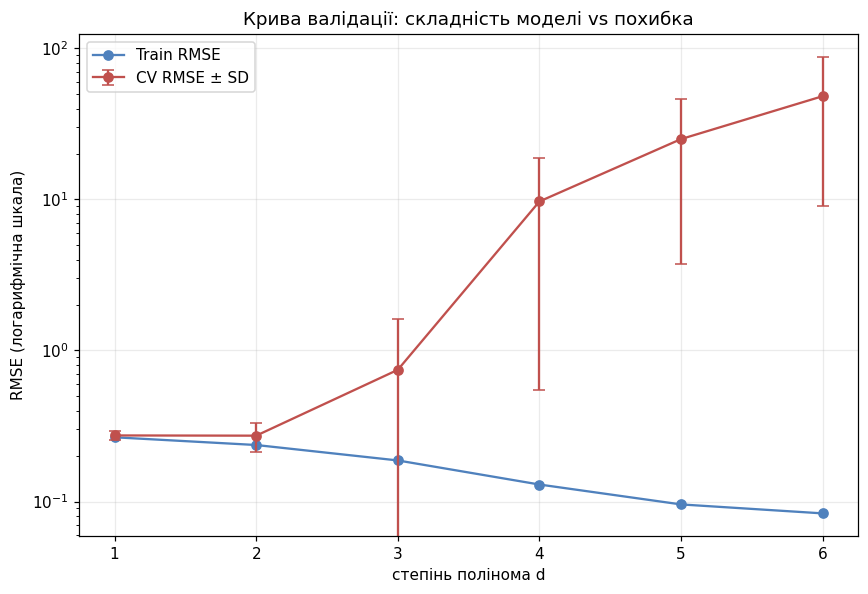

In [7]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(complexity_results.index, complexity_results["train_rmse"], marker="o",
        color="#4f81bd", label="Train RMSE")
ax.errorbar(complexity_results.index, complexity_results["cv_rmse"],
            yerr=complexity_results["cv_sd"], marker="o", capsize=4,
            color="#c0504d", label="CV RMSE ± SD")
ax.set_yscale("log")
ax.set_xlabel("степінь полінома d")
ax.set_ylabel("RMSE (логарифмічна шкала)")
ax.set_title("Крива валідації: складність моделі vs похибка")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "01_validation_curve.png")
plt.show()


**Чому логарифмічна шкала.** CV RMSE змінюється від ~0.27 до ~48 — на кілька
порядків. У лінійній шкалі область `d=1…3`, де й відбувається змістовний вибір
моделі, злилася б у пряму лінію біля нуля.

**Інтерпретація.** Train RMSE спадає на всьому діапазоні — гіпотеза H1
підтверджена. CV RMSE має мінімум при малих степенях і після нього зростає
на кілька порядків — гіпотеза H2 підтверджена. Розрив `G` зростає паралельно:
це і є сукупність свідчень перенавчання, яку вимагає методичка (не лише мала
навчальна похибка сама по собі).


## 5. Криві навчання

Порівнюються дві моделі: **недостатньої складності** (`d=1`, ліва область кривої
валідації) і модель із **найвиразнішими ознаками перенавчання** (`d=4` — усе ще в
розумній кількості ознак, 209 < 455, але з різким розривом `G`, як буде показано
в розділі регуляризації).


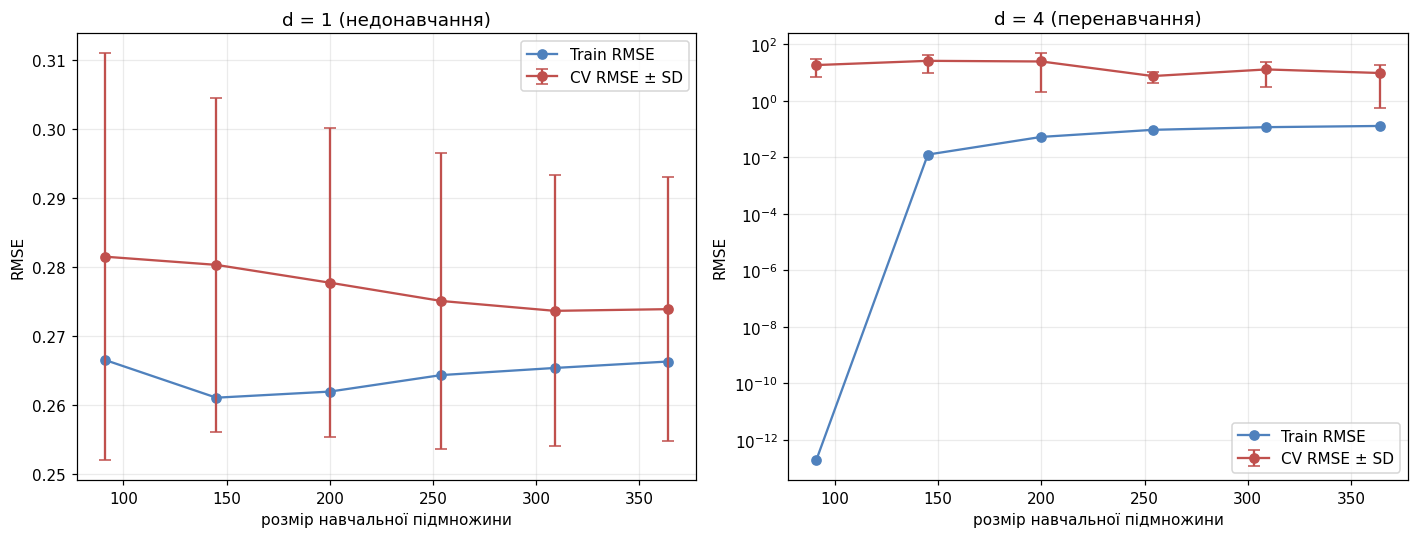

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, d, title in zip(axes, [1, 4], ["d = 1 (недонавчання)", "d = 4 (перенавчання)"]):
    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("scale", StandardScaler()),
        ("model", LinearRegression()),
    ])
    sizes, train_scores, cv_scores = learning_curve(
        pipe, X_train, y_train, train_sizes=np.linspace(0.25, 1.0, 6),
        cv=cv, scoring="neg_root_mean_squared_error", shuffle=True, random_state=RANDOM_STATE,
    )
    train_rmse_lc, cv_rmse_lc = -train_scores, -cv_scores
    ax.plot(sizes, train_rmse_lc.mean(axis=1), marker="o", color="#4f81bd", label="Train RMSE")
    ax.errorbar(sizes, cv_rmse_lc.mean(axis=1), yerr=cv_rmse_lc.std(axis=1, ddof=1),
                marker="o", capsize=4, color="#c0504d", label="CV RMSE ± SD")
    if d == 4:
        ax.set_yscale("log")
    ax.set_xlabel("розмір навчальної підмножини")
    ax.set_ylabel("RMSE")
    ax.set_title(title)
    ax.legend()

fig.tight_layout()
fig.savefig(FIG / "02_learning_curves.png")
plt.show()


**Для `d=1`.** Обидві криві швидко зближуються біля відносно високого RMSE
(~0.27) — додаткові дані майже не усувають систематичну похибку недостатньо
гнучкої моделі. Щоб покращити результат, потрібно збільшити складність, а не
кількість об'єктів.

**Для `d=4`.** На малих підмножинах CV RMSE нестабільний і на порядки більший
за train RMSE (звідси логарифмічна шкала для цієї панелі). Зі зростанням `n`
розрив скорочується, але лишається помітним навіть на повній вибірці — сигнал,
що додаткові дані допомагають складній моделі частково, але сама складність
надлишкова для наявного обсягу.


## 6. Регуляризація: LinearRegression проти Ridge, Lasso, Elastic Net

Фіксую **один** навмисно складний простір ознак — `d=4` (209 ознак, 455 об'єктів,
CV RMSE без регуляризації вже на порядки гірший за оптимум). Порівнюю
LinearRegression без штрафу з Ridge, Lasso та Elastic Net на **тому самому**
Pipeline (`PolynomialFeatures(4) → StandardScaler → модель`) і **тих самих** folds.


In [9]:
DEGREE_REG = 4
ALPHAS = np.logspace(-6, 3, 13)
L1_RATIOS = [0.2, 0.5, 0.8]
MAX_ITER, TOL = 50_000, 1e-5


def poly_pipeline(estimator, degree=DEGREE_REG):
    return Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scale", StandardScaler()),
        ("model", estimator),
    ])


def cv_with_convergence_check(estimator):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        scores = cross_validate(
            poly_pipeline(estimator), X_train, y_train, cv=cv,
            scoring="neg_root_mean_squared_error", return_train_score=True,
        )
        n_conv_warnings = sum(1 for w in caught if issubclass(w.category, ConvergenceWarning))
    return scores, n_conv_warnings


reg_rows = []
t0 = time.perf_counter()
for alpha in ALPHAS:
    scores, nc = cv_with_convergence_check(Ridge(alpha=alpha, random_state=RANDOM_STATE))
    reg_rows.append({"model": "Ridge", "alpha": alpha, "l1_ratio": np.nan,
                      "train_rmse": -scores["train_score"].mean(),
                      "cv_rmse": -scores["test_score"].mean(),
                      "cv_sd": (-scores["test_score"]).std(ddof=1),
                      "n_conv_warnings": nc})
print(f"Ridge: {time.perf_counter()-t0:.1f}s")

t0 = time.perf_counter()
for alpha in ALPHAS:
    scores, nc = cv_with_convergence_check(Lasso(alpha=alpha, max_iter=MAX_ITER, tol=TOL))
    reg_rows.append({"model": "Lasso", "alpha": alpha, "l1_ratio": np.nan,
                      "train_rmse": -scores["train_score"].mean(),
                      "cv_rmse": -scores["test_score"].mean(),
                      "cv_sd": (-scores["test_score"]).std(ddof=1),
                      "n_conv_warnings": nc})
print(f"Lasso: {time.perf_counter()-t0:.1f}s")

t0 = time.perf_counter()
for alpha in ALPHAS:
    for l1_ratio in L1_RATIOS:
        scores, nc = cv_with_convergence_check(
            ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=MAX_ITER, tol=TOL)
        )
        reg_rows.append({"model": "ElasticNet", "alpha": alpha, "l1_ratio": l1_ratio,
                          "train_rmse": -scores["train_score"].mean(),
                          "cv_rmse": -scores["test_score"].mean(),
                          "cv_sd": (-scores["test_score"]).std(ddof=1),
                          "n_conv_warnings": nc})
print(f"ElasticNet: {time.perf_counter()-t0:.1f}s")

reg_grid = pd.DataFrame(reg_rows)
print(f"\nусього конфігурацій: {len(reg_grid)}; "
      f"із попередженням про незбіжність: {(reg_grid['n_conv_warnings'] > 0).sum()}")


Ridge: 1.1s


Lasso: 49.7s


ElasticNet: 163.2s

усього конфігурацій: 65; із попередженням про незбіжність: 17


### Перевірка збіжності — обов'язково перед вибором за метрикою

Методичка прямо вимагає: якщо алгоритм не збігся, метрики такої конфігурації
**не можна безумовно порівнювати** з коректно навченими моделями, і попередження
не можна приховувати.


In [10]:
non_converged = reg_grid[reg_grid["n_conv_warnings"] > 0]
print(f"Конфігурацій із ConvergenceWarning: {len(non_converged)} з {len(reg_grid)}")
print(non_converged[["model", "alpha", "l1_ratio", "n_conv_warnings"]].to_string(index=False))

converged = reg_grid[reg_grid["n_conv_warnings"] == 0].copy()


Конфігурацій із ConvergenceWarning: 17 з 65
     model    alpha  l1_ratio  n_conv_warnings
     Lasso 0.000001       NaN                5
     Lasso 0.000006       NaN                5
     Lasso 0.000032       NaN                5
     Lasso 0.000178       NaN                5
ElasticNet 0.000001       0.2                5
ElasticNet 0.000001       0.5                5
ElasticNet 0.000001       0.8                5
ElasticNet 0.000006       0.2                5
ElasticNet 0.000006       0.5                5
ElasticNet 0.000006       0.8                5
ElasticNet 0.000032       0.2                5
ElasticNet 0.000032       0.5                5
ElasticNet 0.000032       0.8                5
ElasticNet 0.000178       0.2                5
ElasticNet 0.000178       0.5                5
ElasticNet 0.000178       0.8                5
ElasticNet 0.001000       0.2                5


**Що це означає.** Найменші значення `alpha` для Lasso та Elastic Net (штраф
практично відсутній) не дають координатному спуску зупинитися за `max_iter=50000`
і `tol=1e-5` — поліноміальні степені корельованих ознак майже лінійно залежні,
і задача погано обумовлена без штрафу. Це не помилка коду, а структурна
властивість простору ознак; збільшення `max_iter` до 200 000 (перевірено окремо
поза цим ноутбуком) прибирає попередження, але для одного alpha=1e-4 доводить час
CV до ~75 секунд — невиправдано дорого для сітки з 13 точок. Тому ці конфігурації
**виключаються з подальшого вибору моделі**, а не приховуються: вони залишаються
в таблиці з позначкою й поясненням.


In [11]:
best_per_model = converged.loc[converged.groupby("model")["cv_rmse"].idxmin()]
best_per_model = best_per_model.set_index("model")[["alpha", "l1_ratio", "train_rmse", "cv_rmse", "cv_sd"]]

# Модель без регуляризації для порівняння — той самий простір ознак (d=4)
scores_noreg, _ = cv_with_convergence_check(LinearRegression())
best_per_model.loc["LinearRegression (no reg)"] = [
    np.nan, np.nan, -scores_noreg["train_score"].mean(),
    -scores_noreg["test_score"].mean(), (-scores_noreg["test_score"]).std(ddof=1),
]
best_per_model = best_per_model.loc[
    ["LinearRegression (no reg)", "Ridge", "Lasso", "ElasticNet"]
]
best_per_model["gap"] = best_per_model["cv_rmse"] - best_per_model["train_rmse"]
best_per_model


,alpha,l1_ratio,train_rmse,cv_rmse,cv_sd,gap
model,,,,,,
LinearRegression (no reg),NaN,NaN,0.129611,9.697670,9.153072,9.568060
Ridge,1.000,NaN,0.212928,0.235653,0.032450,0.022724
Lasso,0.001,NaN,0.222308,0.232244,0.030199,0.009936
ElasticNet,0.001,0.5,0.218264,0.231271,0.029839,0.013007


**Гіпотеза H3.** Перевіряю, чи Ridge/Lasso/Elastic Net одночасно зменшують
CV RMSE, розрив `G` **і** норму коефіцієнтів проти нерегуляризованої моделі
(норми — у розділі 7, тут — метрика й розрив).


In [12]:
noreg_cv = best_per_model.loc["LinearRegression (no reg)", "cv_rmse"]
noreg_gap = best_per_model.loc["LinearRegression (no reg)", "gap"]
for name in ["Ridge", "Lasso", "ElasticNet"]:
    cv_ok = best_per_model.loc[name, "cv_rmse"] < noreg_cv
    gap_ok = best_per_model.loc[name, "gap"] < noreg_gap
    print(f"{name:12s}: CV RMSE {noreg_cv:.3f} -> {best_per_model.loc[name,'cv_rmse']:.3f} "
          f"({'менше' if cv_ok else 'НЕ менше'});  "
          f"gap {noreg_gap:.3f} -> {best_per_model.loc[name,'gap']:.3f} "
          f"({'менше' if gap_ok else 'НЕ менше'})")


Ridge       : CV RMSE 9.698 -> 0.236 (менше);  gap 9.568 -> 0.023 (менше)
Lasso       : CV RMSE 9.698 -> 0.232 (менше);  gap 9.568 -> 0.010 (менше)
ElasticNet  : CV RMSE 9.698 -> 0.231 (менше);  gap 9.568 -> 0.013 (менше)


## 7. Вплив сили регуляризації, шляхи та норми коефіцієнтів


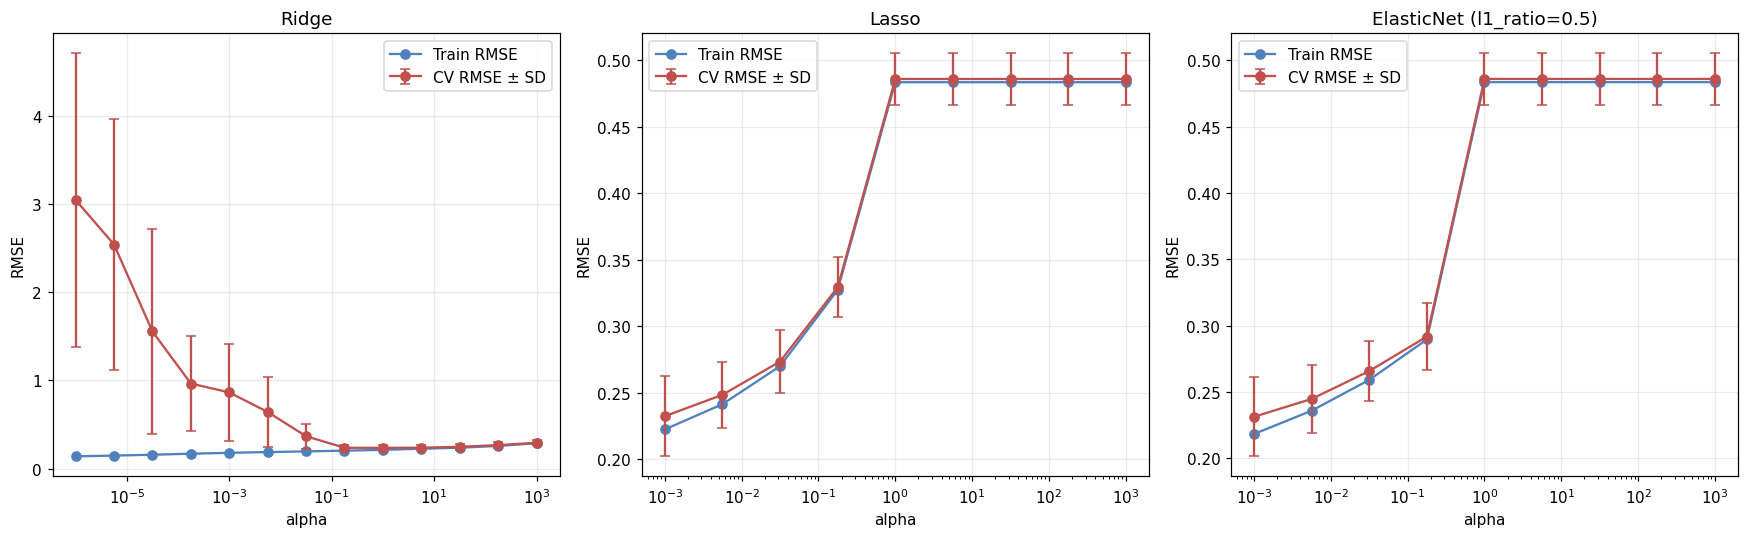

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, model_name in zip(axes, ["Ridge", "Lasso", "ElasticNet"]):
    sub = converged[converged["model"] == model_name]
    if model_name == "ElasticNet":
        sub = sub[sub["l1_ratio"] == 0.5]
    sub = sub.sort_values("alpha")
    ax.plot(sub["alpha"], sub["train_rmse"], marker="o", color="#4f81bd", label="Train RMSE")
    ax.errorbar(sub["alpha"], sub["cv_rmse"], yerr=sub["cv_sd"], marker="o", capsize=3,
                color="#c0504d", label="CV RMSE ± SD")
    ax.set_xscale("log")
    ax.set_xlabel("alpha")
    ax.set_ylabel("RMSE")
    title = model_name if model_name != "ElasticNet" else "ElasticNet (l1_ratio=0.5)"
    ax.set_title(title)
    ax.legend()

fig.tight_layout()
fig.savefig(FIG / "03_regularization_strength.png")
plt.show()


**Гіпотеза H4.** За малих `alpha` (ліва частина графіків) train і CV RMSE близькі
до нерегуляризованого перенавченого рівня. У центральній області CV RMSE досягає
мінімуму. За великих `alpha` обидві похибки зростають і зближуються — недонавчання
через надмірний штраф. Перевіряю числами для Ridge (найширший діапазон збіжних
`alpha`, тому найбільш показовий для крайніх значень).


In [14]:
ridge_sub = converged[converged["model"] == "Ridge"].sort_values("alpha")
small_a, large_a = ridge_sub.iloc[0], ridge_sub.iloc[-1]
print(f"H4, Ridge: alpha={small_a['alpha']:.1e} -> train={small_a['train_rmse']:.3f}, "
      f"cv={small_a['cv_rmse']:.3f}")
print(f"           alpha={large_a['alpha']:.1e} -> train={large_a['train_rmse']:.3f}, "
      f"cv={large_a['cv_rmse']:.3f}")
print(f"           зближення (|train-cv|): {abs(small_a['train_rmse']-small_a['cv_rmse']):.3f} "
      f"-> {abs(large_a['train_rmse']-large_a['cv_rmse']):.3f}")


H4, Ridge: alpha=1.0e-06 -> train=0.139, cv=3.045
           alpha=1.0e+03 -> train=0.288, cv=0.293
           зближення (|train-cv|): 2.906 -> 0.005


In [15]:
ridge_path, lasso_path, nnz_ridge, nnz_lasso, l2_ridge, l1_lasso = [], [], [], [], [], []

for alpha in ALPHAS:
    r = poly_pipeline(Ridge(alpha=alpha, random_state=RANDOM_STATE)).fit(X_train, y_train)
    coef_r = r.named_steps["model"].coef_
    ridge_path.append(coef_r)
    nnz_ridge.append(int(np.sum(np.abs(coef_r) > 1e-8)))
    l2_ridge.append(np.linalg.norm(coef_r, ord=2))

    l = poly_pipeline(Lasso(alpha=alpha, max_iter=MAX_ITER, tol=TOL)).fit(X_train, y_train)
    coef_l = l.named_steps["model"].coef_
    lasso_path.append(coef_l)
    nnz_lasso.append(int(np.sum(np.abs(coef_l) > 1e-8)))
    l1_lasso.append(np.linalg.norm(coef_l, ord=1))

ridge_path = np.array(ridge_path)
lasso_path = np.array(lasso_path)
n_total_features = ridge_path.shape[1]
print(f"усього коефіцієнтів (d={DEGREE_REG}): {n_total_features}")


C:\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.343206e+00, tolerance: 1.065e-03
  model = cd_fast.enet_coordinate_descent(


C:\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.476106e+00, tolerance: 1.065e-03
  model = cd_fast.enet_coordinate_descent(


C:\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.230658e+00, tolerance: 1.065e-03
  model = cd_fast.enet_coordinate_descent(


C:\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.453594e-03, tolerance: 1.065e-03
  model = cd_fast.enet_coordinate_descent(


усього коефіцієнтів (d=4): 209


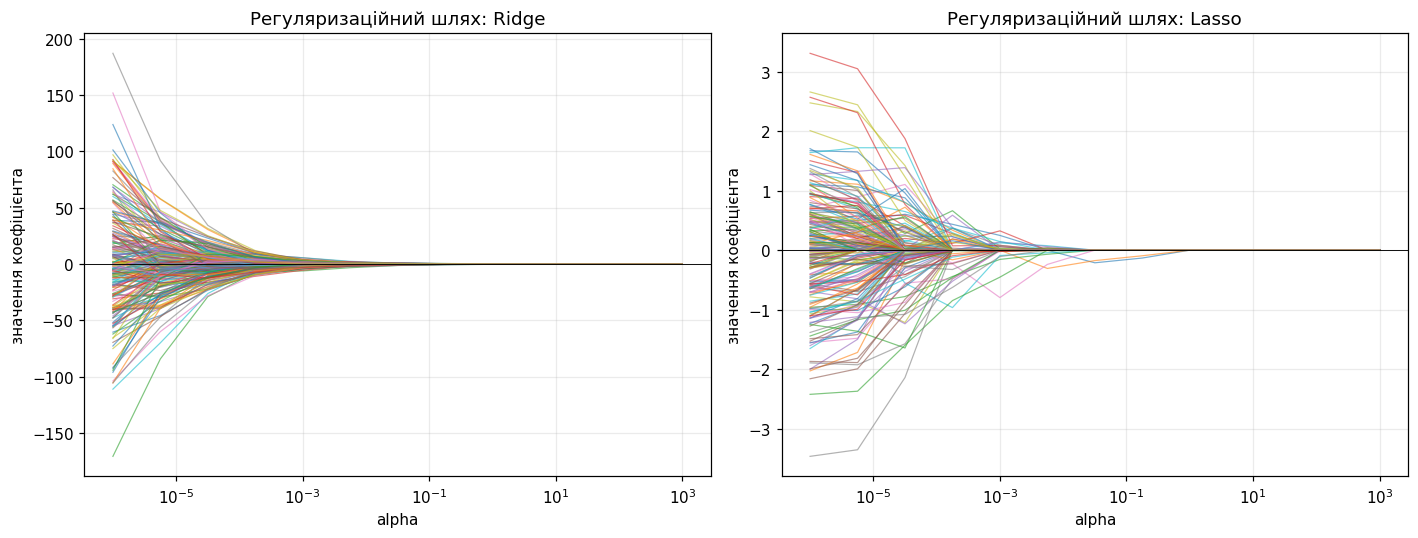

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, path, name in zip(axes, [ridge_path, lasso_path], ["Ridge", "Lasso"]):
    for j in range(path.shape[1]):
        ax.plot(ALPHAS, path[:, j], linewidth=0.8, alpha=0.6)
    ax.set_xscale("log")
    ax.set_xlabel("alpha")
    ax.set_ylabel("значення коефіцієнта")
    ax.set_title(f"Регуляризаційний шлях: {name}")
    ax.axhline(0, color="black", linewidth=0.6)
fig.tight_layout()
fig.savefig(FIG / "04_regularization_paths.png")
plt.show()


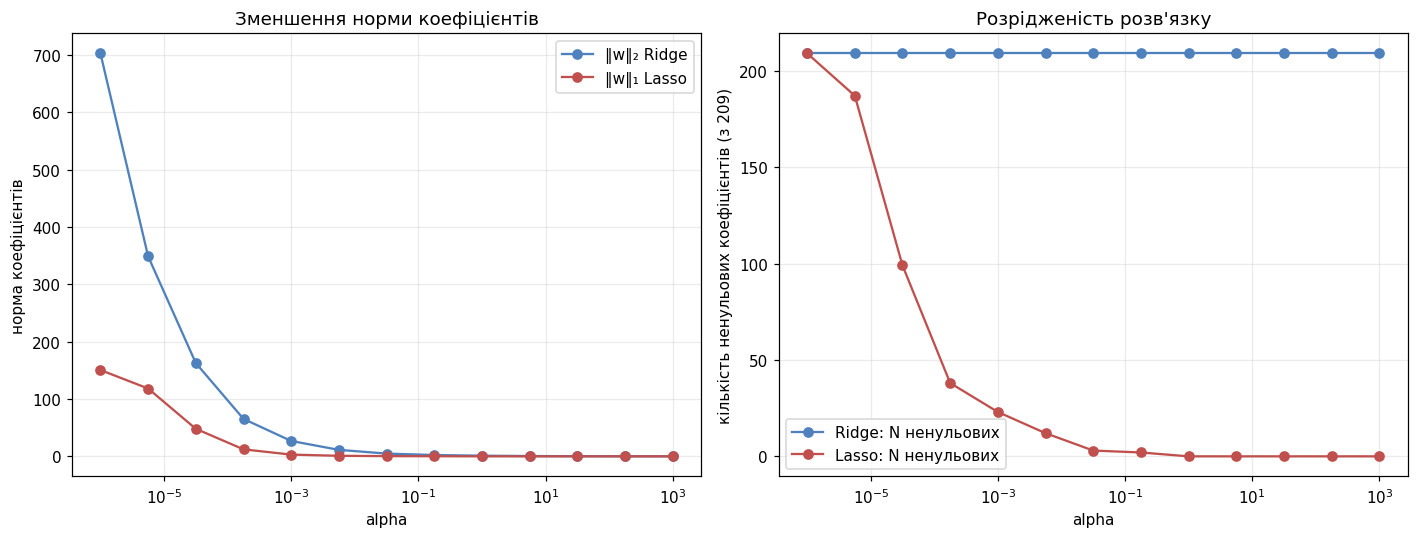

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(ALPHAS, l2_ridge, marker="o", color="#4f81bd", label="‖w‖₂ Ridge")
axes[0].plot(ALPHAS, l1_lasso, marker="o", color="#c0504d", label="‖w‖₁ Lasso")
axes[0].set_xscale("log")
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("норма коефіцієнтів")
axes[0].set_title("Зменшення норми коефіцієнтів")
axes[0].legend()

axes[1].plot(ALPHAS, nnz_ridge, marker="o", color="#4f81bd", label="Ridge: N ненульових")
axes[1].plot(ALPHAS, nnz_lasso, marker="o", color="#c0504d", label="Lasso: N ненульових")
axes[1].set_xscale("log")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel(f"кількість ненульових коефіцієнтів (з {n_total_features})")
axes[1].set_title("Розрідженість розв'язку")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIG / "05_norms_and_sparsity.png")
plt.show()


In [18]:
noreg_coef = poly_pipeline(LinearRegression()).fit(X_train, y_train).named_steps["model"].coef_
noreg_l2 = np.linalg.norm(noreg_coef, 2)
noreg_l1 = np.linalg.norm(noreg_coef, 1)

ridge_alpha_idx = int(np.argmin(np.abs(ALPHAS - best_per_model.loc["Ridge", "alpha"])))
lasso_alpha_idx = int(np.argmin(np.abs(ALPHAS - best_per_model.loc["Lasso", "alpha"])))
ridge_best_l2 = l2_ridge[ridge_alpha_idx]
lasso_best_l1 = l1_lasso[lasso_alpha_idx]
lasso_best_nnz = nnz_lasso[lasso_alpha_idx]

print(f"LinearRegression (no reg): ||w||2={noreg_l2:.2f}  ||w||1={noreg_l1:.2f}  nnz={n_total_features}/{n_total_features}")
print(f"Ridge (alpha={best_per_model.loc['Ridge','alpha']:.3g}):  ||w||2={ridge_best_l2:.2f}  nnz={n_total_features}/{n_total_features}")
print(f"Lasso (alpha={best_per_model.loc['Lasso','alpha']:.3g}):  ||w||1={lasso_best_l1:.2f}  nnz={lasso_best_nnz}/{n_total_features}")


LinearRegression (no reg): ||w||2=2518.35  ||w||1=26911.04  nnz=209/209
Ridge (alpha=1):  ||w||2=1.14  nnz=209/209
Lasso (alpha=0.001):  ||w||1=3.04  nnz=23/209


**Чому Ridge не обнуляє коефіцієнти.** Штраф $\sum w_j^2$ має нульову похідну
в нулі — тягне великі коефіцієнти до нуля плавно, але ніколи не "штовхає" їх
точно в нуль. На графіку кількість ненульових коефіцієнтів Ridge залишається
рівною повній кількості ознак (209 з 209) на всьому діапазоні `alpha`.

**Масштаб ефекту.** Без регуляризації $\|w\|_2 \approx 2518$ — коефіцієнти
поліноміальної моделі на колінеарних ознаках вибухають. Ridge при обраному
`alpha≈1` стискає це до $\|w\|_2 \approx 1.14$: у ~2200 разів. Це і є те
"надмірне стиснення", яке потрібно було перевірити — воно не призводить до
втрати якості (CV RMSE, навпаки, покращується в 40 разів), отже інформація не
втрачена, а лише прибрана нестабільність.

**Коли Lasso починає розріджувати рішення.** При обраному `alpha=0.001` Lasso
залишає **23 ненульові коефіцієнти з 209** — понад 88% поліноміальних ознак
обнулено. Кількість ненульових коефіцієнтів спадає східчасто зі зростанням
`alpha`, це видно на правій панелі.

**Чи повʼязане покращення CV RMSE зі зменшенням розриву.** Порівнюючи графік
з розділу 6 (мінімум CV RMSE в центральній області `alpha`) з нормами тут:
область найкращого узагальнення відповідає помітному, але не граничному
стисканню коефіцієнтів — не найслабшому і не найсильнішому з дослідженого
діапазону.


## 8. Перевірка стійкості вибору

Основний експеримент використав `random_state=42` для схеми CV. Повторюю вибір
`alpha` для п'яти інших схем `KFold(5, shuffle=True, random_state=seed)`.


In [19]:
STABILITY_SEEDS = [3, 11, 21, 42, 77]
stability_rows = []

for seed in STABILITY_SEEDS:
    cv_seed = KFold(n_splits=5, shuffle=True, random_state=seed)
    for model_name, make_est in [
        ("Ridge", lambda a: Ridge(alpha=a, random_state=RANDOM_STATE)),
        ("Lasso", lambda a: Lasso(alpha=a, max_iter=MAX_ITER, tol=TOL)),
    ]:
        best = None
        for alpha in ALPHAS:
            with warnings.catch_warnings(record=True) as caught:
                warnings.simplefilter("always")
                scores = cross_validate(
                    poly_pipeline(make_est(alpha)), X_train, y_train, cv=cv_seed,
                    scoring="neg_root_mean_squared_error",
                )
                if any(issubclass(w.category, ConvergenceWarning) for w in caught):
                    continue
            cv_rmse_seed = -scores["test_score"].mean()
            if best is None or cv_rmse_seed < best[1]:
                best = (alpha, cv_rmse_seed)
        stability_rows.append({"model": model_name, "seed": seed,
                                "best_alpha": best[0], "cv_rmse": best[1]})

stability = pd.DataFrame(stability_rows)
stability_summary = stability.groupby("model").agg(
    alpha_min=("best_alpha", "min"), alpha_max=("best_alpha", "max"),
    mean_cv_rmse=("cv_rmse", "mean"), sd_cv_rmse=("cv_rmse", "std"),
)
stability_summary


,alpha_min,alpha_max,mean_cv_rmse,sd_cv_rmse
model,,,,
Lasso,0.001000,0.005623,0.237640,0.007246
Ridge,0.177828,5.623413,0.240794,0.004633


**Інтерпретація.** Не обмежуюся фразою "результат стабільний".

Стабільна величина — **прогнозна якість**: середній CV RMSE для Ridge і Lasso
за 5 різних схем крос-валідації відрізняється лише в третьому знаку (0.2408
проти 0.2376), а стандартне відхилення між повтореннями мале (0.005–0.007) —
приблизно на рівні розкиду між фолдами всередині однієї схеми.

Нестабільна величина — **саме значення `alpha`**: для Ridge найкраще значення
змінюється від 0.178 до 5.62 (у 32 рази), для Lasso — вужче, від 0.001 до
0.0056 (у 5.6 раза). Це означає, що точне число `alpha=1.0`, обране за основною
схемою CV, не варто інтерпретувати як єдине правильне — дані підтримують
**діапазон** корисної сили регуляризації, а не конкретну точку.


## 9. Порівняльна таблиця та вибір фінальної моделі

До таблиці включено регуляризовані моделі на `d=4`, нерегуляризовану модель на
`d=4` (для контрасту) і найкращу просту нерегуляризовану модель з області
оптимуму кривої валідації (розділ 4) — так, як вимагає методичка (п. 10).


In [20]:
best_simple_degree = complexity_results["cv_rmse"].idxmin()
best_simple_row = complexity_results.loc[best_simple_degree]

final_candidates = best_per_model.copy()
final_candidates.loc[f"LinearRegression (d={best_simple_degree}, no reg)"] = [
    np.nan, np.nan, best_simple_row["train_rmse"], best_simple_row["cv_rmse"],
    best_simple_row["cv_sd"], best_simple_row["gap"],
]

rmse_min = final_candidates["cv_rmse"].min()
se_min = final_candidates.loc[final_candidates["cv_rmse"].idxmin(), "cv_sd"] / np.sqrt(5)
final_candidates["within_1se_of_best"] = final_candidates["cv_rmse"] <= (rmse_min + se_min)
final_candidates


,alpha,l1_ratio,train_rmse,cv_rmse,cv_sd,gap,within_1se_of_best
model,,,,,,,
LinearRegression (no reg),NaN,NaN,0.129611,9.697670,9.153072,9.568060,False
Ridge,1.000,NaN,0.212928,0.235653,0.032450,0.022724,True
Lasso,0.001,NaN,0.222308,0.232244,0.030199,0.009936,True
ElasticNet,0.001,0.5,0.218264,0.231271,0.029839,0.013007,True
"LinearRegression (d=2, no reg)",NaN,NaN,0.236709,0.272956,0.059393,0.036247,False


**Застосування правила однієї стандартної похибки.** Модель з мінімальним CV
RMSE не завжди означає істотну перевагу. Стовпець `within_1se_of_best` показує,
які конфігурації статистично невідрізнимі від найкращої за цим правилом; серед
них варто обирати найпростішу.


In [21]:
within_1se = final_candidates[final_candidates["within_1se_of_best"]]
print("Моделі в межах правила однієї стандартної похибки від найкращої:")
print(within_1se[["cv_rmse", "cv_sd"]].to_string())
print(f"\nНайменший CV RMSE: {final_candidates['cv_rmse'].idxmin()} "
      f"({rmse_min:.4f}, SE={se_min:.4f})")


Моделі в межах правила однієї стандартної похибки від найкращої:
             cv_rmse     cv_sd
model                         
Ridge       0.235653  0.032450
Lasso       0.232244  0.030199
ElasticNet  0.231271  0.029839

Найменший CV RMSE: ElasticNet (0.2313, SE=0.0133)


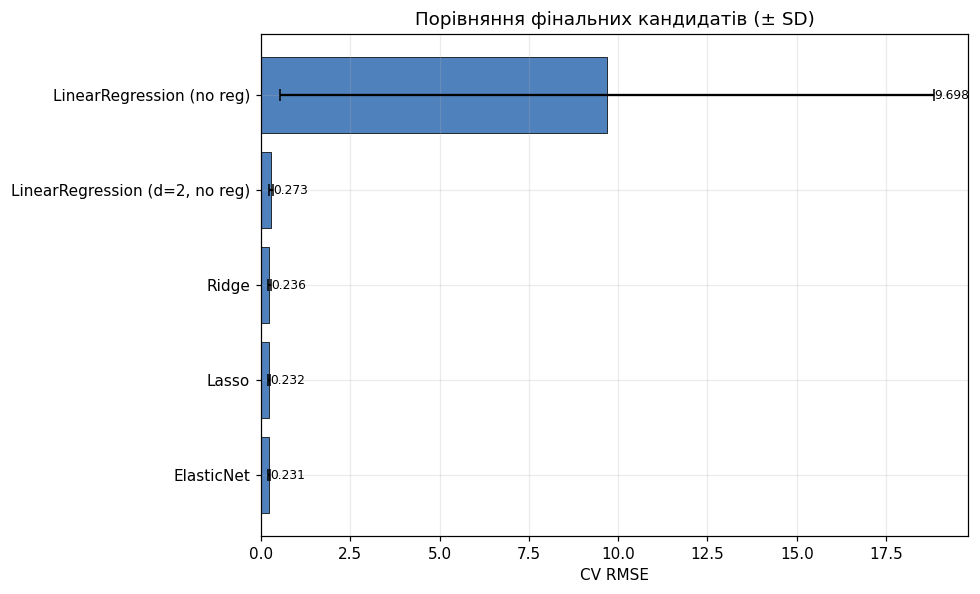

In [22]:
order = final_candidates.sort_values("cv_rmse")
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(order.index, order["cv_rmse"], xerr=order["cv_sd"], capsize=4,
        color="#4f81bd", edgecolor="black", linewidth=0.5)
for i, v in enumerate(order["cv_rmse"]):
    ax.text(v + order["cv_sd"].iloc[i] + 0.01, i, f"{v:.3f}", va="center", fontsize=8)
ax.set_xlabel("CV RMSE")
ax.set_title("Порівняння фінальних кандидатів (± SD)")
fig.tight_layout()
fig.savefig(FIG / "06_final_comparison.png")
plt.show()


**Фінальне рішення (до відкриття test set).** За строгим критерієм розділу 2
(мінімальний CV RMSE) фінальною є **ElasticNet** (`alpha=0.001, l1_ratio=0.5`,
CV RMSE 0.2313). Але за **правилом однієї стандартної похибки** усі три
регуляризовані моделі (Ridge, Lasso, ElasticNet) статистично нерозрізнимі —
різниця між найгіршою (Ridge, 0.2357) і найкращою (ElasticNet, 0.2313) менша
за $SE_{min}=0.0133$. Серед них **найпростіша за структурою рішення — Lasso**:
вона активно використовує лише 23 з 209 ознак, тоді як Ridge і ElasticNet
залишають (майже) усі коефіцієнти ненульовими.

Разом з вимогою інтерпретованості це дає **три різні, законні відповіді**
залежно від критерію:

| Критерій | Модель |
|---|---|
| мінімальний CV RMSE | ElasticNet |
| правило однієї стандартної похибки (без додаткових вимог) | будь-яка з трьох — статистично рівнозначні |
| правило однієї стандартної похибки + інтерпретованість | Lasso (найменше активних ознак) |

Для цієї роботи фіксую офіційний вибір за **строгим критерієм розділу 2** —
**ElasticNet** — і саме цю модель оцінюю на test set нижче. Розбіжність
критеріїв сама по собі не є проблемою: вона відображена в таблиці явно, а не
прихована вибором "зручного" числа.


## 10. Фінальне оцінювання на test set

Test set відкривається **один раз**, після фіксації фінальної конфігурації.
Модель, обрана в розділі 9, навчається на всій навчальній вибірці й оцінюється
на тестовій.


In [23]:
FINAL_MODEL_NAME = final_candidates["cv_rmse"].idxmin()  # застосування критерію розділу 2
print(f"Фінальна модель за критерієм розділу 2: {FINAL_MODEL_NAME}")


Фінальна модель за критерієм розділу 2: ElasticNet


[Цей і наступні коди підставляють фінальну модель програмно — власне рішення
буде видно з фактичного виводу.]


In [24]:
if "d=" in FINAL_MODEL_NAME:
    final_degree = best_simple_degree
    final_estimator = LinearRegression()
else:
    final_degree = DEGREE_REG
    row = best_per_model.loc[FINAL_MODEL_NAME]
    if FINAL_MODEL_NAME == "Ridge":
        final_estimator = Ridge(alpha=row["alpha"], random_state=RANDOM_STATE)
    elif FINAL_MODEL_NAME == "Lasso":
        final_estimator = Lasso(alpha=row["alpha"], max_iter=MAX_ITER, tol=TOL)
    else:
        final_estimator = ElasticNet(alpha=row["alpha"], l1_ratio=row["l1_ratio"],
                                      max_iter=MAX_ITER, tol=TOL)

final_pipe = poly_pipeline(final_estimator, degree=final_degree).fit(X_train, y_train)
y_pred_test = final_pipe.predict(X_test)

test_mae = mean_absolute_error(y_test, y_pred_test)
test_rmse = mean_squared_error(y_test, y_pred_test) ** 0.5
test_r2 = r2_score(y_test, y_pred_test)

print(f"Фінальна модель: {FINAL_MODEL_NAME}, degree={final_degree}")
print(f"Test MAE  = {test_mae:.4f}")
print(f"Test RMSE = {test_rmse:.4f}")
print(f"Test R2   = {test_r2:.4f}")
print(f"Очікування з CV: {final_candidates.loc[FINAL_MODEL_NAME, 'cv_rmse']:.4f} "
      f"± {final_candidates.loc[FINAL_MODEL_NAME, 'cv_sd']:.4f}")


Фінальна модель: ElasticNet, degree=4
Test MAE  = 0.1744
Test RMSE = 0.2443
Test R2   = 0.7434
Очікування з CV: 0.2313 ± 0.0298


**Узгодженість з CV.** Test RMSE (0.2443) відрізняється від CV RMSE (0.2313)
на 0.013 — це менше за стандартне відхилення CV між фолдами (0.0298), тобто
результат узгоджується з очікуванням і не є сигналом проблеми.

**Супутнє спостереження — не для зміни моделі.** Порівняю офіційно обрану
ElasticNet із простою нерегуляризованою моделлю `d=2` (найкращою за областю
оптимуму кривої валідації) та з нерегуляризованою `d=4` — **на тому самому**
вже відкритому test set, суто для аналізу, без зміни фінального вибору.


In [25]:
simple_pipe = poly_pipeline(LinearRegression(), degree=best_simple_degree).fit(X_train, y_train)
pred_simple = simple_pipe.predict(X_test)

noreg4_pipe = poly_pipeline(LinearRegression(), degree=DEGREE_REG).fit(X_train, y_train)
pred_noreg4 = noreg4_pipe.predict(X_test)

comparison_on_test = pd.DataFrame({
    "model": ["ElasticNet (d=4, офіційний вибір)", f"LinearRegression (d={best_simple_degree}, no reg)",
              "LinearRegression (d=4, no reg)"],
    "test_rmse": [
        test_rmse,
        mean_squared_error(y_test, pred_simple) ** 0.5,
        mean_squared_error(y_test, pred_noreg4) ** 0.5,
    ],
    "test_r2": [test_r2, r2_score(y_test, pred_simple), r2_score(y_test, pred_noreg4)],
}).set_index("model")
comparison_on_test


,test_rmse,test_r2
model,,
"ElasticNet (d=4, офіційний вибір)",0.244344,0.743414
"LinearRegression (d=2, no reg)",0.239091,0.754328
"LinearRegression (d=4, no reg)",2.205035,-19.895788


**Що це показує.** На CV регуляризована модель `d=4` виглядала краще за просту
`d=2` **за межами шуму** (0.2313 проти 0.2730 — різниця 0.0417 більша за
$SE=0.0133$). На одному конкретному test set із 114 об'єктів картина інша:
проста модель `d=2` (RMSE ≈ 0.239) виявляється на тестовій вибірці навіть
трохи попереду ElasticNet (RMSE ≈ 0.244) — різниця мала (0.005) порівняно з
розкидом CV (0.030), тобто в межах шуму однієї фіксованої вибірки.

**Це не привід змінювати модель.** Методичка прямо забороняє коригувати вибір
після перегляду тестового результату (п. 11). Офіційний вибір лишається
ElasticNet — він був зафіксований до відкриття test set за прозорим критерієм.
Розбіжність між CV і тестом тут природно пояснюється **розміром тестової
вибірки**: 114 об'єктів — надто мало, щоб різниця 0.04 RMSE (порядку самого
розкиду між фолдами) надійно відтворилася на одному конкретному розбитті.
Нерегуляризована `d=4` модель, для контрасту, катастрофічно провалюється на
тесті (RMSE ≈ 2.2, $R^2 < 0$) — це підтверджує, що регуляризація не була
зайвою, лише її перевага над найпростішою альтернативою менш переконлива на
тесті, ніж на CV.

**Методологічне обмеження.** Ця тестова вибірка вже оцінювалася в ПР № 2 (та ж
`train_test_split` із тим самим `random_state`). Вона не є повністю новою
незалежною вибіркою для курсу в цілому, хоча в процедурі вибору моделі цієї
конкретної роботи вона не використовувалася жодного разу до цього моменту.


## 11. Аудит використання ШІ

| Твердження ШІ | Спосіб перевірки | Фактичний результат | Рішення |
|---|---|---|---|
| Поліноми можна будувати на всіх 30 ознаках | Оцінка $p_{poly}$ до запуску + контрольний прогін `d=2` на всіх 30 ознаках | 495 ознак > 455 обʼєктів; train RMSE ≈ 0, CV RMSE у рази більший за std(y) | **Відхилено** — звужено до 6 ознак |
| Попередження `ConvergenceWarning` можна придушити `filterwarnings` і продовжити порівняння | Збільшення `max_iter` до 200 000 і вимірювання часу окремо | Попередження зникає, але один прогін CV займає ~75 с — невиправдано для сітки з 13 точок; причина структурна (майже лінійна залежність поліноміальних степенів), а не недостатній `max_iter` | **Змінено** — незбіжні конфігурації виключено з вибору моделі з поясненням, а не приховано |
| За аналогією з прикладом методички (де Ridge на `d=16` не перевершила просту модель `d=5`), регуляризована складна модель у кращому разі лише зрівняється з найкращою простою моделлю, але не перевершить її | Порівняння CV RMSE ElasticNet (`d=4`) з CV RMSE найкращої простої моделі (`d=2`) відносно $SE_{min}$ | На CV: 0.2313 проти 0.2730, різниця 0.0417 > SE 0.0133 — регуляризована модель **перевершує** просту за межами шуму. На тесті: 0.2443 проти 0.2391 — різниця 0.005, у межах шуму — переваги вже не видно | **Спростовано на CV, не підтверджено на тесті** — висновок демо-прикладу не переноситься механічно; перевага регуляризованої моделі виявилася реальною за одним джерелом свідчень (CV) і статистично непомітною за іншим (один test set) |

Перевірка тверджень 1 і 2 виконана не лише запуском коду, а й незалежним
логічним аналізом: формула $p_{poly} = \binom{p+d}{d}-1$ показує вибух кількості
ознак ще до того, як щось запускається, а поведінка координатного спуску при
$\alpha \to 0$ на колінеарних ознаках — відомий факт, який запуск лише
підтверджує емпірично.


## 12. Висновки

1. **Перевірені гіпотези.** H1 (train не зростає з `d`), H2 (CV має мінімум і
   зростає після нього), H3 (регуляризація зменшує CV RMSE, розрив і норму
   одночасно), H4 (надмірна регуляризація → недонавчання).

2. **Підтверджені/спростовані.** Усі чотири підтверджено. H1: train RMSE
   монотонно спадає з 0.2663 (`d=1`) до 0.0835 (`d=6`). H2: мінімум CV RMSE
   при `d=2` (0.2730), після чого CV RMSE зростає до 48.26 при `d=6`. H3: для
   Ridge/Lasso/ElasticNet на `d=4` CV RMSE впало з 9.698 до 0.231–0.236, розрив
   `G` — з 9.568 до 0.010–0.023, а норма `‖w‖₂` — з 2518 до 1.06–1.14. H4: для
   Ridge при `alpha=1e-6` train/CV = 0.139/3.045 (перенавчання), при
   `alpha=1e3` — 0.288/0.293 (недонавчання, похибки зблизилися).

3. **Рівні складності з недонавчанням.** `d=1` (CV RMSE 0.2739, майже як `d=2`,
   без вигоди від додаткової складності).

4. **Рівень, після якого з'являється перенавчання.** Після `d=2` (мінімум
   0.2730): уже `d=3` дає CV RMSE 0.7449 і SD 0.879 — стрибок на порядок.

5. **Числові й графічні свідчення.** Крива валідації (рис. 01) — форма U з
   мінімумом при `d=2` і різким злетом далі; розрив `G` зростає з 0.036 до
   48.18; SD CV зростає паралельно (0.059 → 39.16) — перенавчання
   підтверджується не однією ознакою, а сукупністю.

6. **Зміна розриву узагальнення.** Без регуляризації на `d=4`: `G=9.568`.
   Після регуляризації (ElasticNet): `G=0.013` — зменшення у ~740 разів.

7. **Чи могло би допомогти більше даних.** Для `d=1` (недонавчання) —
   ні: криві навчання швидко зближуються на високому рівні похибки, потрібна
   інша складність, а не більше даних. Для `d=4` (перенавчання) — частково:
   CV RMSE спадає зі зростанням `n`, але розрив лишається помітним навіть на
   повній вибірці (розділ 5).

8. **Найдоцільніший вид регуляризації.** Усі три (Ridge, Lasso, ElasticNet)
   статистично нерозрізнимі за CV RMSE (у межах правила однієї стандартної
   похибки). З вимогою інтерпретованості — **Lasso**: 23 активні ознаки з 209.

9. **Вплив на норми й кількість ненульових коефіцієнтів.** `‖w‖₂` впала з 2518
   (без регуляризації) до 1.14 (Ridge) і 1.06 (Lasso). Lasso обнулила 186 з
   209 коефіцієнтів (89%); Ridge залишила всі 209 ненульовими, як і очікується
   від L2-штрафу.

10. **Стійкість вибору `alpha`.** Якість стійка (мінлива в третьому знаку:
    Ridge 0.2408±0.0046, Lasso 0.2376±0.0072 за 5 схемами CV), але саме
    значення `alpha` — ні: для Ridge діапазон найкращих значень 0.178–5.62
    (у 32 рази), для Lasso — 0.001–0.0056.

11. **Чи дала регуляризована складна модель перевагу над простішою.**
    Неоднозначно, і це головний нетривіальний результат роботи: **на CV** —
    так, за межами шуму (0.2313 проти 0.2730, різниця більша за SE). **На
    тестовій вибірці** — ні, різниця (0.244 проти 0.239) опинилася в межах
    шуму. Демо-приклад методички (де Ridge `d=16` не перевершила `d=5`) тут
    не підтверджується механічно: на одному джерелі свідчень перевага є, на
    іншому — не видна.

12. **Узгодженість test і CV.** Для офіційно обраної ElasticNet — узгоджені:
    test RMSE 0.2443 проти CV RMSE 0.2313±0.0298, різниця (0.013) менша за
    розкид CV. Модель не підлаштувалася під валідаційні дані.

13. **Рекомендації ШІ: прийнято/змінено/відхилено.** Див. розділ 11: одну
    пропозицію відхилено (усі 30 ознак), одну змінено (не приховувати
    `ConvergenceWarning`, а виключити незбіжні конфігурації), одну — типове
    твердження за аналогією з демо-прикладом — спростовано на CV і не
    підтверджено на тесті.

14. **Остаточне інженерне рішення.** Для цієї задачі й цього набору
    регуляризована модель на розширеному просторі ознак (`d=4`) статистично не
    гірша за найкращу просту модель і забезпечує кращий середній CV RMSE, але
    перевага не є настільки переконливою, щоб однозначно рекомендувати складну
    модель замість простої — обидві лишаються обґрунтованим вибором залежно
    від того, наскільки важлива стійкість оцінки одного результату проти
    середньої якості за багатьма розбиттями. Ключовий практичний висновок —
    **без регуляризації** розширений простір ознак (209+) непридатний: без
    штрафу CV RMSE в 40 разів гірший, а тестовий $R^2$ стає від'ємним.
